In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

In [2]:
low_path = "LOL-v2/train/low"
high_path = "LOL-v2/train/high"

image_name = os.listdir(low_path)[0]

low_img = cv2.imread(
    os.path.join(low_path, image_name)
)

high_img = cv2.imread(
    os.path.join(high_path, image_name)
)

low_img = cv2.cvtColor(
    low_img,
    cv2.COLOR_BGR2RGB
)

high_img = cv2.cvtColor(
    high_img,
    cv2.COLOR_BGR2RGB
)

In [3]:
def apply_hist_eq(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.equalizeHist(gray)

In [4]:
def apply_clahe(image,
                clip=2.0,
                grid=(8,8)):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=clip,
        tileGridSize=grid
    )

    return clahe.apply(gray)

In [5]:
def apply_gamma(image,
                gamma=0.5):

    normalized = image / 255.0

    corrected = np.power(
        normalized,
        gamma
    )

    corrected = (
        corrected * 255
    ).astype(np.uint8)

    return corrected

In [6]:
hist_eq_img = apply_hist_eq(low_img)

clahe_img = apply_clahe(low_img)

gamma_img = apply_gamma(low_img)

In [7]:
# Peak Signal-to-Noise Ratio(PSNR)
# how close reconstructed image is to ground truth

In [8]:
# PSNR=10*log({MAX_I^2}/{MSE})
# human perception is nonlinear

In [9]:
gray_high = cv2.cvtColor(
    high_img,
    cv2.COLOR_RGB2GRAY
)

In [10]:
psnr_hist_eq = peak_signal_noise_ratio(
    gray_high,
    hist_eq_img
)

psnr_clahe = peak_signal_noise_ratio(
    gray_high,
    clahe_img
)

psnr_gamma = peak_signal_noise_ratio(
    high_img,
    gamma_img
)

In [11]:
print("PSNR Hist Eq:", psnr_hist_eq)
print("PSNR CLAHE:", psnr_clahe)
print("PSNR Gamma:", psnr_gamma)

PSNR Hist Eq: 14.236028247557844
PSNR CLAHE: 11.344307850013063
PSNR Gamma: 14.678624787065482


In [12]:
# PSNR < 20       : poor
# PSNR = 20 - 30  : acceptable
# PSNR > 30       : good


In [13]:
# Structural Similarity Index (SSIM)

In [14]:
ssim_hist_eq = structural_similarity(
    gray_high,
    hist_eq_img
)

ssim_clahe = structural_similarity(
    gray_high,
    clahe_img
)

ssim_gamma = structural_similarity(
    high_img,
    gamma_img,
    channel_axis=2
)

In [15]:
print("SSIM Hist Eq:", ssim_hist_eq)
print("SSIM CLAHE:", ssim_clahe)
print("SSIM Gamma:", ssim_gamma)

SSIM Hist Eq: 0.4271279779370347
SSIM CLAHE: 0.4855713164201988
SSIM Gamma: 0.649263508924136


In [16]:
# Natural Image Quality Evaluator (NIQE)

In [17]:
import torch
import pyiqa

In [18]:
niqe_metric = pyiqa.create_metric('niqe')

In [19]:
def to_tensor(image):

    image = image.astype(np.float32) / 255.0

    tensor = torch.tensor(image)

    tensor = tensor.permute(2,0,1)

    tensor = tensor.unsqueeze(0)

    return tensor

In [20]:
niqe_gamma = niqe_metric(
    to_tensor(gamma_img)
)

print(niqe_gamma)

tensor(6.4296, dtype=torch.float64)


In [21]:
start = time.time()

apply_hist_eq(low_img)

end = time.time()

hist_eq_time = end - start

In [22]:
start = time.time()

apply_clahe(low_img)

end = time.time()

clahe_time = end - start

In [23]:
start = time.time()

apply_gamma(low_img)

end = time.time()

gamma_time = end - start

In [24]:
print(hist_eq_time)
print(clahe_time)
print(gamma_time)

0.000492095947265625
0.0003211498260498047
0.001893758773803711


In [25]:
comparison = pd.DataFrame({

    "Method": [
        "Hist Eq",
        "CLAHE",
        "Gamma"
    ],

    "PSNR": [
        psnr_hist_eq,
        psnr_clahe,
        psnr_gamma
    ],

    "SSIM": [
        ssim_hist_eq,
        ssim_clahe,
        ssim_gamma
    ],

    "Inference Time": [
        hist_eq_time,
        clahe_time,
        gamma_time
    ]

})

comparison

,Method,PSNR,SSIM,Inference Time
0,Hist Eq,14.236028,0.427128,0.000492
1,CLAHE,11.344308,0.485571,0.000321
2,Gamma,14.678625,0.649264,0.001894


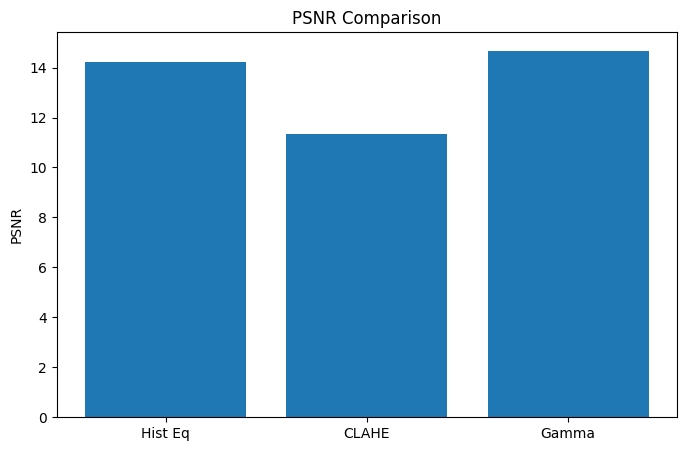

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["PSNR"]
)

plt.title("PSNR Comparison")
plt.ylabel("PSNR")

plt.show()

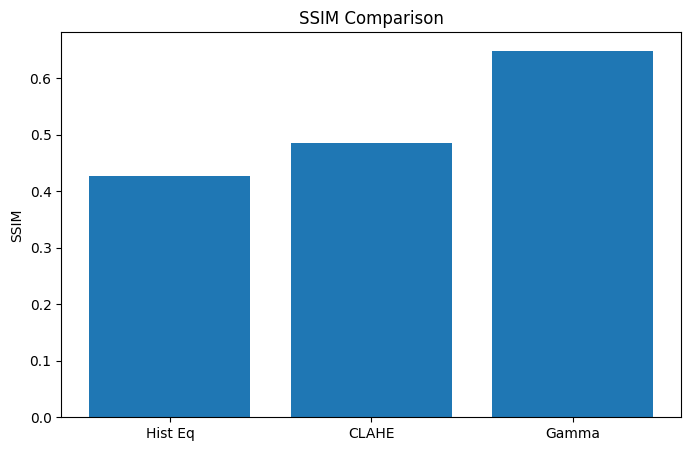

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["SSIM"]
)

plt.title("SSIM Comparison")
plt.ylabel("SSIM")

plt.show()

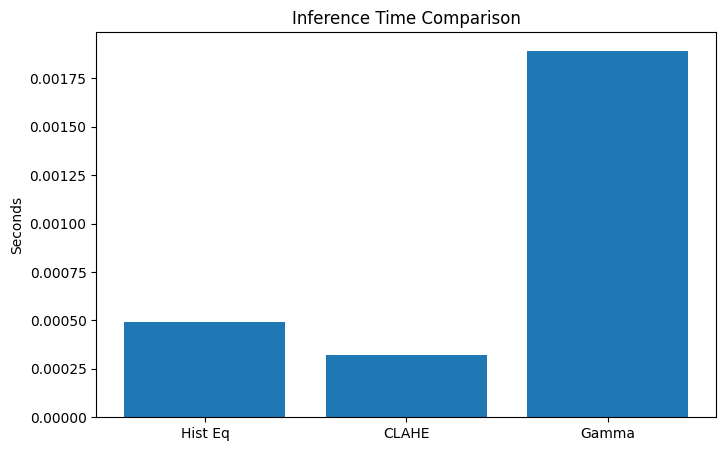

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["Inference Time"]
)

plt.title("Inference Time Comparison")
plt.ylabel("Seconds")

plt.show()